七分类

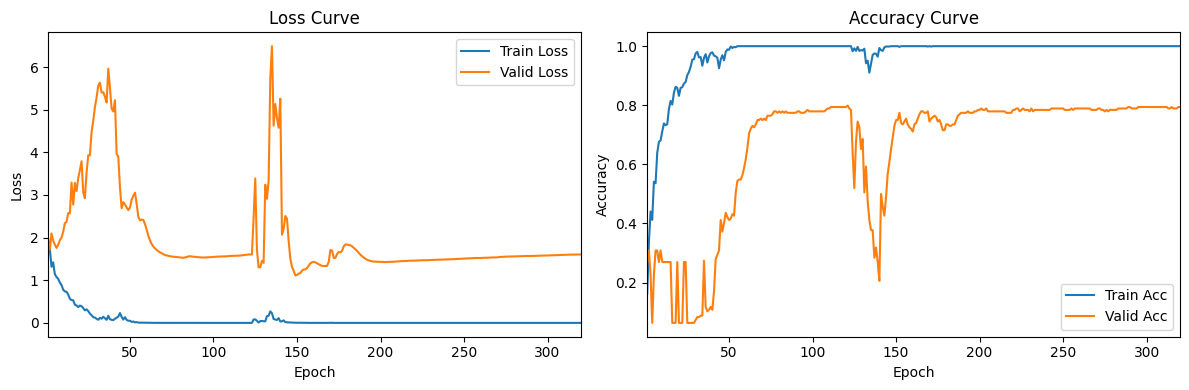

Epoch 320/320 │ Train Loss: 0.0000, Train Acc: 1.0000 │ Val Loss: 1.6050, Val Acc: 0.7941

Evaluation of model 1 (Validation Accuracy: 0.7990)
Accuracy on All Data: 0.9598


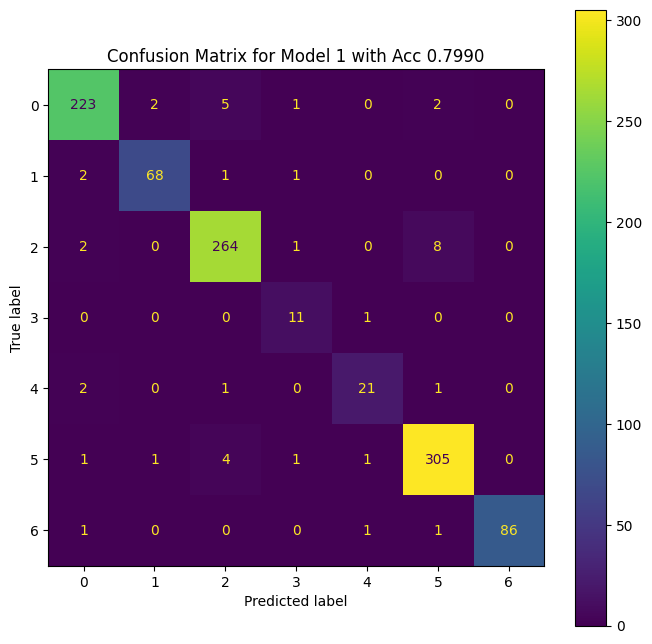


Evaluation of model 2 (Validation Accuracy: 0.7941)
Accuracy on All Data: 0.9588


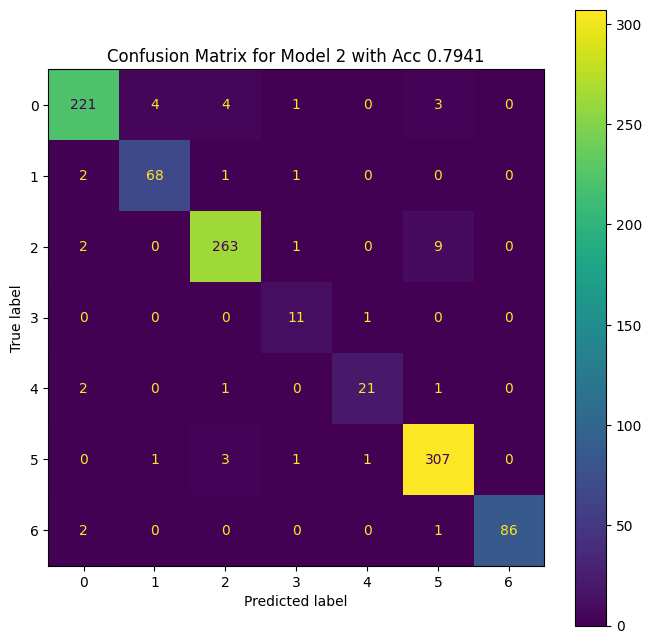

In [1]:
import os
os.environ["TORCHDYNAMO_DISABLE"] = "1"
import numpy as np
import librosa
import torch
torch._dynamo.disable()
import torch.nn.functional as F
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib
import sys
import matplotlib.pyplot as plt
from d2l import torch as d2l
if hasattr(torch._dynamo, 'disable'):
    torch._dynamo.disable()


# 参数设置
root_dir = r"C:\Users\nihao\Desktop\Database\植物种类七分类\wavs_1+3"
sample_rate = 320000
duration = 0.004
num_samples = int(sample_rate * duration)
batch_size = 512
num_epochs = 320

lr = 0.0008
top_n = 2  # 保存最好的2个模型

# 最佳模型的文件夹
best_model_dir = os.path.join(os.path.dirname(root_dir), 'best_path')
os.makedirs(best_model_dir, exist_ok=True)


# 数据集类
class AudioDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.classes = [d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))]
        self.file_paths = []
        self.labels = []

        for idx, class_name in enumerate(self.classes):
            class_dir = os.path.join(root_dir, class_name)
            for root, _, files in os.walk(class_dir):
                for file in files:
                    if file.endswith('.wav'):
                        self.file_paths.append(os.path.join(root, file))
                        self.labels.append(idx)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.labels[idx]
        audio, sr = librosa.load(file_path, sr=sample_rate, mono=True)

        # 填充或截断音频到固定长度
        if len(audio) < num_samples:
            audio = np.pad(audio, (0, num_samples - len(audio)), 'constant')
        else:
            audio = audio[:num_samples]

        if self.transform:
            audio = self.transform(audio)
        return audio, label


# 数据预处理
transform = lambda x: torch.tensor(x, dtype=torch.float32)

# 加载数据
dataset = AudioDataset(root_dir, transform=transform)

# 划分训练集和验证集
train_size = int(0.80 * len(dataset))
valid_size = len(dataset) - train_size
train_dataset, valid_dataset = random_split(dataset, [train_size, valid_size])

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)


# CNN + Transformer 模型定义
class AudioClassifier(nn.Module):
    def __init__(self, num_classes):
        super(AudioClassifier, self).__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=3, stride=1, padding=1)
        self.bn1 = nn.BatchNorm1d(64)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm1d(128)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=3, stride=1, padding=1)
        self.bn3 = nn.BatchNorm1d(256)
        self.conv4 = nn.Conv1d(256, 512, kernel_size=3, stride=1, padding=1)
        self.bn4 = nn.BatchNorm1d(512)
        # 减少输出大小的关键在于增加池化层的 kernel_size
        self.pool = nn.MaxPool1d(kernel_size=4, stride=4)

        self.convs = nn.Sequential(
            self.conv1,
            self.bn1,
            nn.ReLU(),
            self.pool,
            self.conv2,
            self.bn2,
            nn.ReLU(),
            self.pool,
            self.conv3,
            self.bn3,
            nn.ReLU(),
            self.pool,
            self.conv4,
            self.bn4,
            nn.ReLU(),
            self.pool
        )

        # 动态计算卷积层输出的大小
        self._to_linear = self._get_conv_output(num_samples)

        # Transformer Encoder部分
        self.transformer_layer = nn.TransformerEncoderLayer(d_model=512, nhead=8)
        self.transformer_encoder = nn.TransformerEncoder(self.transformer_layer, num_layers=1)

        self.fc1 = nn.Linear(self._to_linear, 1024)
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)

    def _get_conv_output(self, shape):
        # 使用输入大小 shape 计算输出大小
        o = self.convs(torch.zeros(1, 1, shape))
        self._to_linear = o.shape[1] * o.shape[2]
        return self._to_linear

    def forward(self, x):
        x = x.unsqueeze(1)  # 添加通道维度
        x = self.convs(x)

        # Transformer 部分
        x = x.permute(2, 0, 1)  # 调整形状以适应 Transformer 的输入
        x = self.transformer_encoder(x)
        x = x.permute(1, 2, 0)  # 调整形状以适应全连接层的输入

        x = x.reshape(x.size(0), -1)  # 展平

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# 训练和验证函数，保存最佳的15个模型
def train_and_validate(net, train_loader, valid_loader, num_epochs, lr, device, top_n=2):
    import torch
    import matplotlib.pyplot as plt
    from IPython.display import clear_output, display
    import os

    # 确保模型、优化器、损失函数就绪
    net = net.to(device)
    loss_fn = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(net.parameters(), lr=lr)

    # 用于记录曲线
    train_losses, train_accs = [], []
    valid_losses, valid_accs = [], []

    # 用于维护 top-N 最佳模型 (列表元素为 (val_acc, model_path))
    best_models = []

    for epoch in range(1, num_epochs + 1):
        # ===== 训练阶段 =====
        net.train()
        total_loss, total_correct, total_samples = 0.0, 0, 0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            y_hat = net(X)
            loss = loss_fn(y_hat, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X.size(0)
            total_correct += (y_hat.argmax(dim=1) == y).sum().item()
            total_samples += X.size(0)

        train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples

        # ===== 验证阶段 =====
        net.eval()
        val_loss_sum, val_correct, val_samples = 0.0, 0, 0
        with torch.no_grad():
            for X, y in valid_loader:
                X, y = X.to(device), y.to(device)
                y_hat = net(X)
                loss = loss_fn(y_hat, y)
                val_loss_sum += loss.item() * X.size(0)
                val_correct += (y_hat.argmax(dim=1) == y).sum().item()
                val_samples += X.size(0)

        val_loss = val_loss_sum / val_samples
        val_acc = val_correct / val_samples

        # 记录曲线数据
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        valid_losses.append(val_loss)
        valid_accs.append(val_acc)

        # ===== 保存模型并维护 Top-N 列表 =====
        # 每轮都保存一次，然后挑选前 top_n
        model_path = os.path.join(
            best_model_dir,
            f"epoch{epoch:03d}_valacc{val_acc:.4f}.pth"
        )
        torch.save(net.state_dict(), model_path)
        best_models.append((val_acc, model_path))
        # 按准确率降序排序，保留 top_n
        best_models = sorted(best_models, key=lambda x: x[0], reverse=True)[:top_n]
        # 删除多余文件
        for acc, path in list(best_models[top_n:]):
            if os.path.exists(path):
                os.remove(path)

        # ===== 动态显示图和文字 =====
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        # 左：Loss
        axes[0].plot(range(1, epoch+1), train_losses, label='Train Loss')
        axes[0].plot(range(1, epoch+1), valid_losses, label='Valid Loss')
        axes[0].set_title('Loss Curve')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
        axes[0].set_xlim(1, num_epochs)
        # 右：Accuracy
        axes[1].plot(range(1, epoch+1), train_accs, label='Train Acc')
        axes[1].plot(range(1, epoch+1), valid_accs, label='Valid Acc')
        axes[1].set_title('Accuracy Curve')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
        axes[1].set_xlim(1, num_epochs)

        plt.tight_layout()
        display(fig)
        plt.close(fig)

        # 文字信息
        print(f"Epoch {epoch}/{num_epochs} │ "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} │ "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # 返回最终的 top-N 模型列表
    return best_models




# 评估准确率和生成混淆矩阵
def evaluate_accuracy(data_iter, net, device):
    net.eval()
    metric = [0.0, 0.0]
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for features, labels in data_iter:
            features, labels = features.to(device), labels.to(device)
            outputs = net(features)
            preds = outputs.argmax(axis=1)
            metric[0] += (preds == labels).sum().item()
            metric[1] += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return metric[0] / metric[1], all_preds, all_labels


# 实例化模型并训练
num_classes = 7
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = AudioClassifier(num_classes)
best_models = train_and_validate(net, train_dataloader, valid_dataloader, num_epochs, lr, device)

# 加载并评估保存的每个最佳模型
for idx, (acc, model_path) in enumerate(best_models):
    net.load_state_dict(torch.load(model_path))

    # 使用最佳模型对所有数据进行评估
    all_acc, all_preds, all_labels = evaluate_accuracy(DataLoader(dataset, batch_size=batch_size, shuffle=False), net,
                                                       device)

    print(f'\nEvaluation of model {idx + 1} (Validation Accuracy: {acc:.4f})')
    print(f'Accuracy on All Data: {all_acc:.4f}')

    # 生成并显示最终的混淆矩阵
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(num_classes))

    # 显示混淆矩阵
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax)
    plt.title(f'Confusion Matrix for Model {idx + 1} with Acc {acc:.4f}')
    plt.show()

In [5]:

def evaluate_full_accuracy(model, dataset, device, num_classes):
    model.eval()
    class_correct = [0] * num_classes
    class_total = [0] * num_classes
    all_preds = []
    all_labels = []
    
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(device)
            outputs = model(features)
            _, preds = torch.max(outputs, 1)
            
            # 收集预测和标签
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # 统计每个类别的正确预测数
            for label, pred in zip(labels, preds):
                if label == pred:
                    class_correct[label] += 1
                class_total[label] += 1
    
    # 整体准确率
    total_acc = accuracy_score(all_labels, all_preds)
    
    # 各类别准确率
    class_acc = {}
    for i in range(num_classes):
        if class_total[i] > 0:
            class_acc[i] = class_correct[i] / class_total[i]
        else:
            class_acc[i] = 0.0  # 避免除以0
    
    return total_acc, class_acc

# 加载最佳模型参数
best_model_path = r"C:\Users\nihao\Desktop\Database\植物种类七分类\best_path\epoch115_valacc0.7500.pth"
net.load_state_dict(torch.load(best_model_path))

# 执行全量评估
total_accuracy, class_accuracy = evaluate_full_accuracy(net, dataset, device, num_classes)

# 输出结果
print(f"全体数据集准确率: {total_accuracy:.4f}")
for cls, acc in class_accuracy.items():
    print(f"类别 {cls} 准确率: {acc:.4f}")

# 输出混淆矩阵
cm = confusion_matrix(all_labels, all_preds)
print("\n混淆矩阵:")
print(cm)

NameError: name 'net' is not defined